In [1]:
# import cv2
import numpy as np
import tensorflow as tf

In [2]:
np.__version__

'1.26.4'

In [3]:
tf.__version__

'2.10.1'

In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
image = cv2.imread("./download.jpg")

In [5]:
# cv2.imshow("Image", image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

### Tensorflow


In [5]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Conv2D(16, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(300, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 16)        2320      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 16)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 300)               1

### Giải thích về Output shape và Param
- conv2d: (None, 26, 26, 16) vì kernel_size = 3, strides = 1, padding = 'valid' (không thêm padding) và input_shape = (28, 28, 1)
nên khi trượt kernel 3x3 trên input 28x28 sẽ thu được output 26x26. Số lượng kênh đầu ra là 16 vì có 16 bộ lọc (filters) trong lớp này.

### Train model

In [6]:
minist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = minist.load_data()

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
X_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
X_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

In [9]:
X_train.shape

(60000, 28, 28, 1)

In [10]:
X_test.shape

(10000, 28, 28, 1)

In [11]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [12]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

### Tạo category cho dữ liệu

In [13]:
from keras.utils import to_categorical

In [14]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [15]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], dtype=float32)

In [19]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
# model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test))
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 7s 3ms/step - loss: 0.0098 - accuracy: 0.9967
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0058 - accuracy: 0.9981
Epoch 3/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0057 - accuracy: 0.9980
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0055 - accuracy: 0.9982
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0057 - accuracy: 0.9981


In [17]:
# Save the model
model.save("mnist_model.h5")

ImportError: `save_model()` using h5 format requires h5py. Could not import h5py.

In [1]:
# Đánh giá accuracy trên tập test
model.evaluate(X_test, y_test)

NameError: name 'model' is not defined

### Test

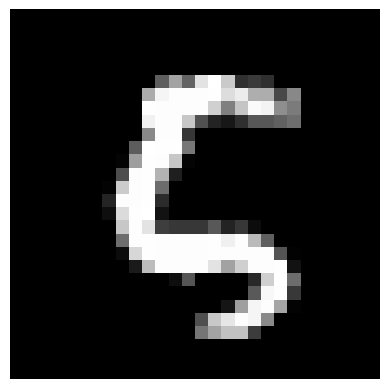

In [31]:
# Show bằng matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("./data-test/anh2.png")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [36]:
# Ảnh số 5
img_test = cv2.imread("./data-test/anh2.png", cv2.IMREAD_GRAYSCALE)
img_test = cv2.resize(img_test, (28, 28))
img_test = img_test.reshape((1, 28, 28, 1))

y_test = model.predict(img_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [37]:
y_test

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

In [38]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: []
